# bioelements — from biosignals to the periodic table, and to materials

Every atom emits light at a characteristic set of wavelengths — its emission
spectrum. `bioelements` octave-folds a biosignal's peaks into the optical band and
asks which elements' lines they land on: the same octave-transpose `biocolors` uses
to send a frequency to a *colour*, `bioelements` uses to send it to the *periodic
table*.

The expansion lifts this from **atoms** to **materials**. A `Composition` is a
weighted bag of elements — or of other compositions — so water, air, wood, a cloud,
any composition of matter, has its own composite spectrum, and therefore its own
chord, tuning, palette, geometry, and biosignal affinity.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
from biotuner import bioelements as be
df = be.load_elements('air')
print(f'{len(df):,} NIST emission lines across {df.element.nunique()} elements')
print('element categories:', ', '.join(sorted(df.type.unique())))

C:\Users\skite\Documents\Github\biotuner\.claude\worktrees\epic-morse-ded0d5\biotuner\biotuner_object.py:11: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof import FOOOF


21,896 NIST emission lines across 99 elements
element categories: Actinides, Alkali Metals, Alkaline Earth Metals, Halogens, Lanthanides, Metalloids, Noble Gases, Nonmetals, Post-transition Metals, Transition Metals


## An element is a spectrum is a chord is a tuning
The atom is already a first-class harmonic object. Take hydrogen's strongest lines,
fold them to audio, reduce to ratios — a **material tuning**.

In [2]:
h = be.element_spectrum('Hydrogen', top=12)
print('hydrogen — strongest folded ratios:', be.material_tuning(be.MATERIALS['Water'], n_steps=6))
print('an element leaf spectrum:', h)

hydrogen — strongest folded ratios: [1.0, 1.08, 1.12, 1.35, 1.4286, 1.512]
an element leaf spectrum: Spectrum('Hydrogen', 12 lines, dominant: Hydrogen 100%)


## Matter is compositions of atoms
Water is H₂O. The composite spectrum is the weighted superposition of its elements'
spectra — but each element must be **budget-normalised** first, or line-rich elements
(oxygen has 3× hydrogen's lines) would dominate regardless of stoichiometry. With
budget-normalisation, water is 2/3 hydrogen, 1/3 oxygen *by design*.

In [3]:
water = be.MATERIALS['Water']
print('water.elements()      ', {k: round(v,3) for k,v in water.elements().items()})
print('spectral dominance    ', {k: round(v,3) for k,v in water.dominant(top=None).items()})
print('air.elements()        ', {k: round(v,3) for k,v in list(be.MATERIALS["Air"].elements().items())[:3]})

water.elements()       {'Hydrogen': 0.667, 'Oxygen': 0.333}
spectral dominance     {'Hydrogen': 0.667, 'Oxygen': 0.333}
air.elements()         {'Nitrogen': 0.78, 'Oxygen': 0.21, 'Argon': 0.009}


## Composition is recursive: a cloud is water + air
A **structure**'s parts are themselves materials, so composition bottoms out at
element leaves through any depth.

In [4]:
cloud = be.MATERIALS['Cloud']
print('cloud.elements()', {k: round(v,3) for k,v in list(cloud.elements().items())[:5]})
print('cloud composite spectrum:', len(cloud.spectrum()), 'lines')

cloud.elements() {'Nitrogen': 0.741, 'Oxygen': 0.216, 'Hydrogen': 0.033, 'Argon': 0.009, 'Carbon': 0.0}
cloud composite spectrum: 280 lines


## The dictionary spans matter — a measured claim
Materials are tagged on four axes (compositional level · material class · natural
domain · element category). `coverage_report()` is a build gate: every class and
domain represented, and the falsifiable metric — ≥ 8 of the 10 NIST element
categories exercised.

In [5]:
rep = be.coverage_report(be.MATERIALS)

bioelements coverage — 153 materials
  kinds:            {'element': 100, 'compound': 32, 'mixture': 16, 'structure': 5}
  classes  14/14: missing none
  domains  7/7: missing none
  element categories 10/10 (gate >=8): PASS
      have:    ['Actinides', 'Alkali Metals', 'Alkaline Earth Metals', 'Halogens', 'Lanthanides', 'Metalloids', 'Noble Gases', 'Nonmetals', 'Post-transition Metals', 'Transition Metals']
      missing: none
  OVERALL: PASS


## A biosignal resonates with materials, not just atoms
Fold a signal's peaks to the optical band and score them against every material's
composite lines (relative, cents-based tolerance). A biosignal now has a graded
affinity to *water*, *wood*, *iron* — the materials it most resonates with.

In [6]:
sig = np.array([7.83, 14.3, 20.8, 27.3, 33.8])   # a Schumann-like signal
ranked = be.match_materials(sig, tol_cents=60)
print(ranked.head(8).to_string(index=False))

        material  affinity     kind archetype
          Galena  0.559888 compound          
          Pyrite  0.539446 compound          
          Quartz  0.475108 compound     earth
     SilicaGlass  0.475108 compound          
    UraniumGlass  0.453835 compound          
         Granite  0.445107  mixture          
          Halite  0.444207 compound          
InterstellarDust  0.441789  mixture          


## Every material affords a palette — its flame colours
Each element burns with a characteristic colour (how chemists identify them by flame:
Na→amber, Cu→green, K→violet, Li→crimson…). A material's palette is the flame colours
of its dominant elements, weighted by composition — so water (H/O) reads nothing like a
copper alloy (green) or table salt (amber+green).

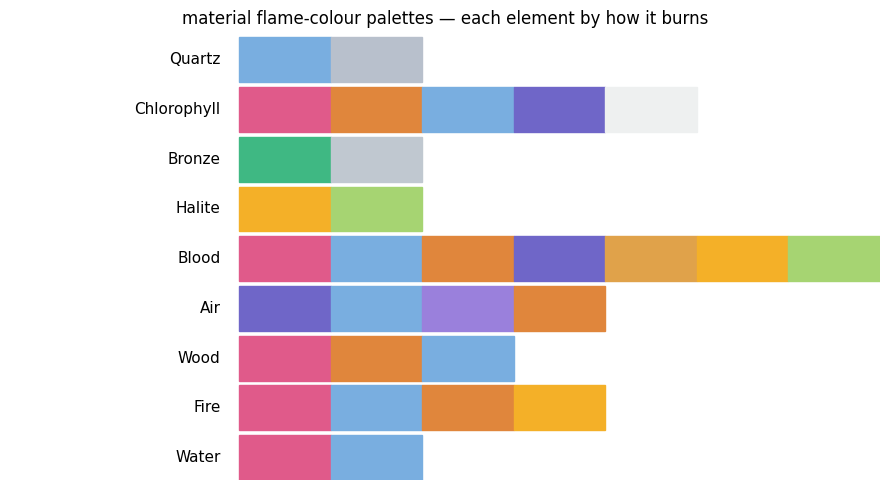

In [7]:
mats = ['Water','Fire','Wood','Air','Blood','Halite','Bronze','Chlorophyll','Quartz']
fig, ax = plt.subplots(figsize=(9, 5))
for row, name in enumerate(mats):
    pal = be.material_flame_palette(be.MATERIALS[name], n=7)
    for col, hexc in enumerate(pal):
        ax.add_patch(plt.Rectangle((col, row), 1, 0.9, color=hexc))
    ax.text(-0.2, row + 0.45, name, ha='right', va='center', fontsize=11)
ax.set_xlim(-2.5, 7); ax.set_ylim(0, len(mats)); ax.axis('off')
ax.set_title('material flame-colour palettes — each element by how it burns')
plt.tight_layout(); plt.show()

## And a tuning, a chord, a form
The same composite spectrum reduces to a material scale, sounds as a material chord,
and hands off to `harmonic_geometry` as a `HarmonicInput` for a material's *shape*.

In [8]:
for name in ['Water','Fire','Iron']:
    m = be.MATERIALS[name]
    print(f'{name:6s} tuning={m.tuning(n_steps=6)}')
gi = be.MATERIALS['Water'].geometry(top=6)
print('\nwater.geometry() ->', type(gi).__name__, 'with', len(gi.peaks), 'partials')

Water  tuning=[1.0, 1.08, 1.12, 1.35, 1.4286, 1.512]
Fire   tuning=[1.0, 1.0083, 1.0456, 1.0468, 1.0531, 1.0618]
Iron   tuning=[1.004, 1.0057, 1.0366, 1.0387, 1.0425, 1.0429]

water.geometry() -> HarmonicInput with 2 partials


## The compositional hierarchy
```
  Element     H, O, C, N, Fe …            leaf spectra (NIST lines)
     |  stoichiometry
  Compound    H2O, NaCl, CO2, cellulose   fixed atom ratios
     |  proportion
  Mixture     air, wood, tissue, blood    blends of compounds/elements
     |  arrangement
  Structure   cloud, fire, lightning      compositions of materials (-> geometry)
```
One recursive operation — *superpose the component spectra, weighted, each
budget-normalised* — carries all four levels. Everything a material affords is a
transform of that one composite spectrum.

## Applied: a night of sleep, read as changing matter
The affinity is not a still image. Run it across a **real night of sleep** (Sleep-EDF
SC4012, EEG Fpz-Cz, 12 real 30-second epochs per stage) and the matter a biosignal
resonates with **shifts with sleep depth** — the same recording, read as a changing
composition of matter.

In [9]:
from pathlib import Path
from scipy.signal import welch, find_peaks
p = Path('sleep_stages.npz')
if not p.exists(): p = Path('docs/examples/bioelements/sleep_stages.npz')
S = np.load(p); epochs, stages, sf = S['epochs'], S['stages'], float(S['sf'])
ORDER = ['W','N1','N2','N3','REM']
print('real sleep epochs:', epochs.shape, '|',
      {s:int((stages==s).sum()) for s in ORDER})

def epoch_peaks(x, sf, n=6, fmin=1.5, fmax=30):
    f, pxx = welch(x, sf, nperseg=int(sf*4)); b=(f>=fmin)&(f<=fmax)
    f, db = f[b], 10*np.log10(pxx[b]+1e-30)
    idx,_ = find_peaks(db, distance=2)
    if len(idx)==0: return np.array([f[np.argmax(db)]])
    return f[np.sort(idx[np.argsort(db[idx])[::-1][:n]])]

real sleep epochs: (60, 3000) | {'W': 12, 'N1': 12, 'N2': 12, 'N3': 12, 'REM': 12}


### Which materials does each sleep stage resonate with?
Per-epoch affinity to a curated set of materials, averaged within each stage — shown
**relative per material** (z-scored across stages) so a stage reads as resonating
*above* or *below* that material's own average, rather than being swamped by
line-dense species that match almost anything.

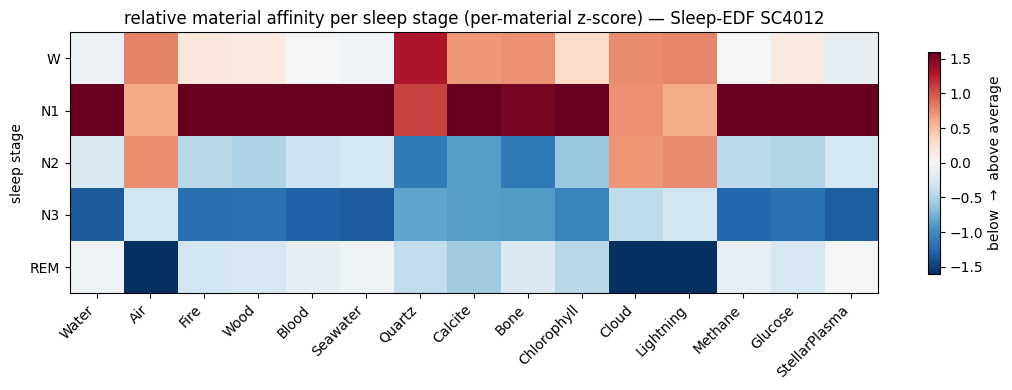

In [10]:
MATS = ['Water','Air','Fire','Wood','Blood','Seawater','Quartz','Calcite','Bone',
        'Chlorophyll','Cloud','Lightning','Methane','Glucose','StellarPlasma']
aff = {s: [] for s in ORDER}
for x, st in zip(epochs, stages):
    pk = epoch_peaks(x, sf)
    aff[str(st)].append([be.material_affinity(pk, be.MATERIALS[m], tol_cents=60) for m in MATS])
H = np.array([np.mean(aff[s], axis=0) for s in ORDER])
Z = (H - H.mean(0)) / (H.std(0) + 1e-9)   # per-material: which stages sit above/below average
fig, ax = plt.subplots(figsize=(11, 4))
im = ax.imshow(Z, aspect='auto', cmap='RdBu_r', vmin=-1.6, vmax=1.6)
ax.set_xticks(range(len(MATS))); ax.set_xticklabels(MATS, rotation=45, ha='right')
ax.set_yticks(range(len(ORDER))); ax.set_yticklabels(ORDER)
ax.set_ylabel('sleep stage')
ax.set_title('relative material affinity per sleep stage (per-material z-score) — Sleep-EDF SC4012')
fig.colorbar(im, ax=ax, label='below  →  above average', shrink=0.85)
plt.tight_layout(); plt.show()

### The elemental *type* signature of each stage
Summing `match_elements` by periodic **category** gives each stage a fingerprint over
the kinds of matter — a stacked profile that shifts as the night deepens.

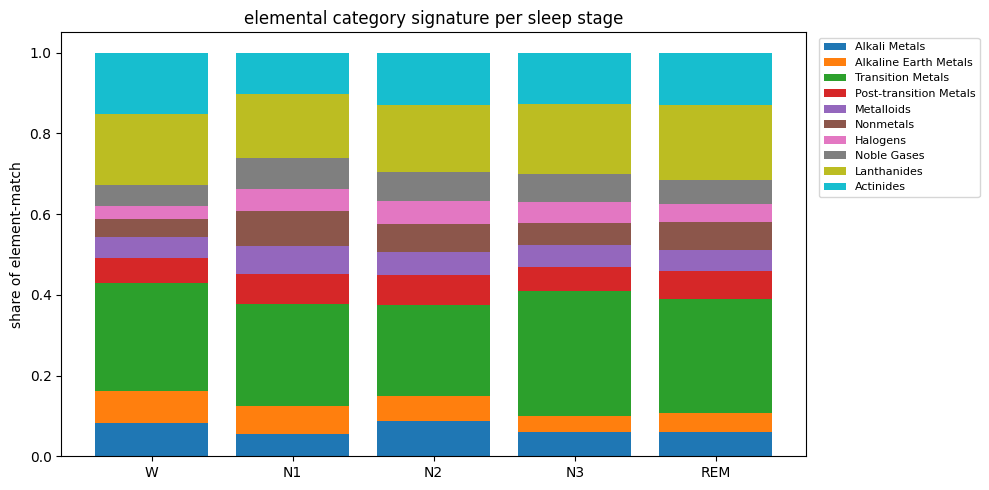

In [11]:
from biotuner.bioelements.tables import ELEMENT_CATEGORIES
import matplotlib.cm as cm
cat_mix = {}
for s in ORDER:
    xs = epochs[stages==s]
    ff, pp = welch(xs[0], sf, nperseg=int(sf*4)); acc = np.zeros_like(pp)
    for x in xs: acc += welch(x, sf, nperseg=int(sf*4))[1]
    b=(ff>=1.5)&(ff<=30); fb, db = ff[b], 10*np.log10(acc[b]/len(xs)+1e-30)
    idx,_ = find_peaks(db, distance=2); top = np.sort(idx[np.argsort(db[idx])[::-1][:6]])
    me = be.match_elements(fb[top], top=30, tol_cents=60)
    bc = me.groupby('category')['score'].sum()
    cat_mix[s] = (bc/bc.sum()).reindex(ELEMENT_CATEGORIES).fillna(0)
fig, ax = plt.subplots(figsize=(10,5)); bottom = np.zeros(len(ORDER))
for c, col in zip(ELEMENT_CATEGORIES, cm.tab10(np.linspace(0,1,len(ELEMENT_CATEGORIES)))):
    vals = [cat_mix[s][c] for s in ORDER]
    ax.bar(ORDER, vals, bottom=bottom, label=c, color=col); bottom = bottom + vals
ax.set_ylabel('share of element-match'); ax.set_title('elemental category signature per sleep stage')
ax.legend(bbox_to_anchor=(1.01,1), loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

### The periodic table itself, lit by resonance
Full granularity: score every one of the 99 elements (`match_elements`) and paint the
result **onto the periodic table**. Each stage lights a different region of the table —
the resonance has structure across the whole of chemistry, not just a top-few list.

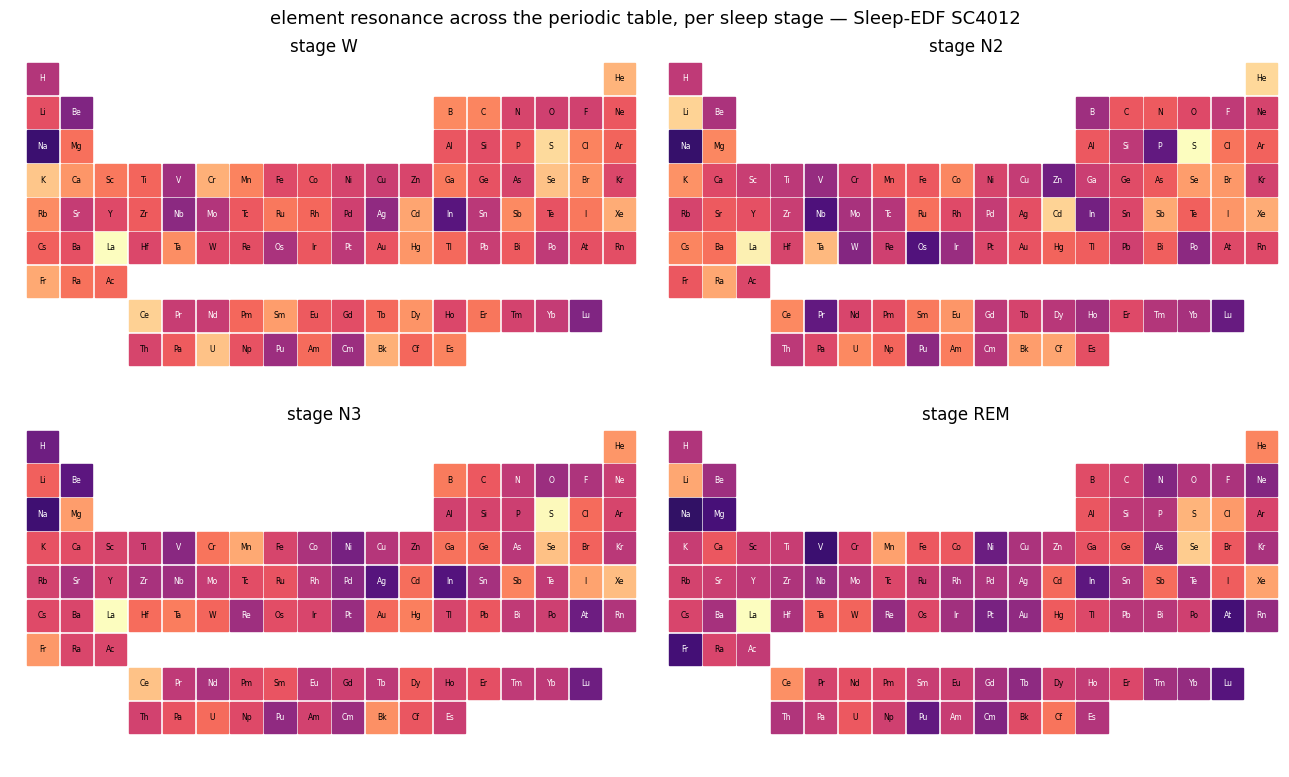

In [12]:
from biotuner.bioelements import periodic as P
PT_STAGES = ['W', 'N2', 'N3', 'REM']
pt_scores = {}
for s in PT_STAGES:
    xs = epochs[stages == s]; acc = None
    for x in xs:
        me = be.match_elements(epoch_peaks(x, sf), top=30, tol_cents=60).set_index('element')['score']
        acc = me if acc is None else acc.add(me, fill_value=0)
    pt_scores[s] = acc / len(xs)

def draw_pt(ax, sc, title):
    vmax = float(sc.max()) or 1e-6
    for name in P.NAMES:
        pos = P.element_position(name)
        if pos is None: continue
        r, c = pos; v = float(sc.get(name, 0.0)) / vmax
        ax.add_patch(plt.Rectangle((c, -r), 0.92, 0.92, color=plt.cm.magma(v)))
        ax.text(c + 0.46, -r + 0.46, P.symbol(name), ha='center', va='center',
                fontsize=5.5, color='white' if v < 0.55 else 'black')
    ax.set_xlim(-0.5, 18); ax.set_ylim(-9, 1); ax.set_aspect('equal'); ax.axis('off')
    ax.set_title(title, fontsize=12)
fig, axs = plt.subplots(2, 2, figsize=(13, 8))
for ax, s in zip(axs.ravel(), PT_STAGES): draw_pt(ax, pt_scores[s], f'stage {s}')
fig.suptitle('element resonance across the periodic table, per sleep stage — Sleep-EDF SC4012', fontsize=13)
plt.tight_layout(); plt.show()

### A whole night, continuously — the resonance river
Not five averages but **139 contiguous epochs** across ~9 hours: each folded to the
optical band and scored by element category, stacked over time under the hypnogram.
The composition of matter the EEG resonates with **flows** as the night unfolds.

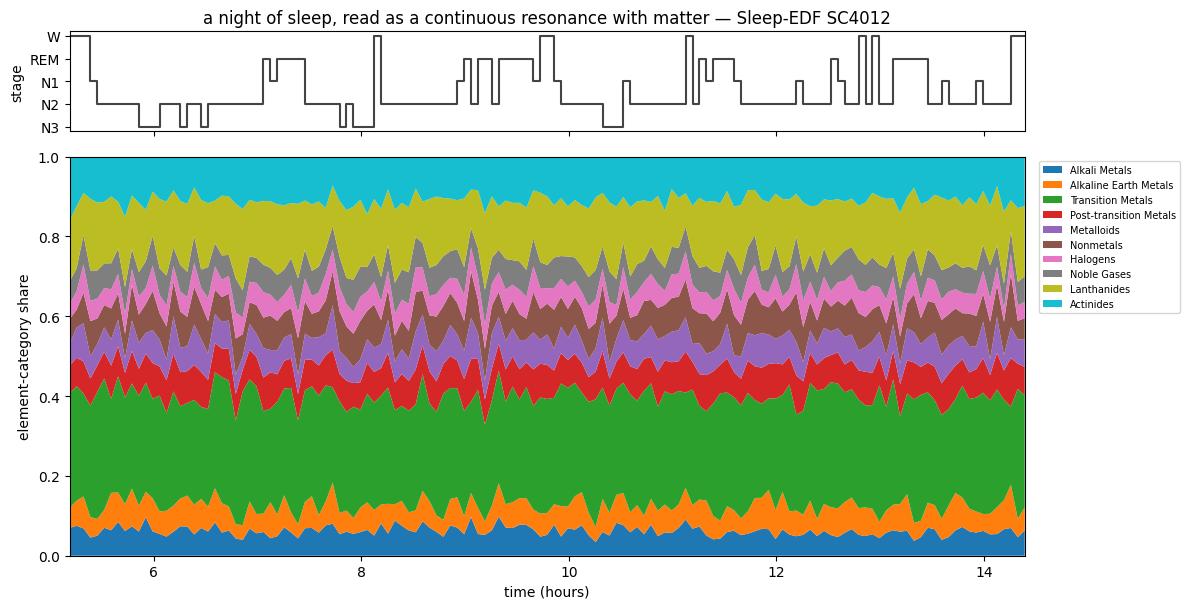

In [13]:
from biotuner.bioelements.tables import ELEMENT_CATEGORIES
import matplotlib.cm as cm
nx, nstg, nt = S['night_epochs'], S['night_stages'], S['night_times_h']
riv = np.zeros((len(nx), len(ELEMENT_CATEGORIES)))
for i, x in enumerate(nx):
    me = be.match_elements(epoch_peaks(x, sf), top=30, tol_cents=60)
    bc = me.groupby('category')['score'].sum().reindex(ELEMENT_CATEGORIES).fillna(0)
    riv[i] = (bc / (bc.sum() + 1e-9)).values
fig, (axh, axr) = plt.subplots(2, 1, figsize=(12, 6.2),
                               gridspec_kw={'height_ratios': [1, 4]}, sharex=True)
sy = {'W': 4, 'REM': 3, 'N1': 2, 'N2': 1, 'N3': 0}
axh.plot(nt, [sy[s] for s in nstg], drawstyle='steps-post', color='#444', lw=1.5)
axh.set_yticks(list(sy.values())); axh.set_yticklabels(list(sy.keys())); axh.set_ylabel('stage')
axh.set_title('a night of sleep, read as a continuous resonance with matter — Sleep-EDF SC4012')
axr.stackplot(nt, riv.T, labels=list(ELEMENT_CATEGORIES),
              colors=cm.tab10(np.linspace(0, 1, len(ELEMENT_CATEGORIES))))
axr.set_xlabel('time (hours)'); axr.set_ylabel('element-category share')
axr.set_ylim(0, 1); axr.set_xlim(float(nt.min()), float(nt.max()))
axr.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)
plt.tight_layout(); plt.show()

As the sleeper descends wake → N1 → N2 → slow-wave N3 and back through REM, the
elements and materials the EEG most resonates with move across the periodic table —
a biosignal's affinity with matter is **stateful**, tracking the brain's own rhythms.